# HAM10000 Model Training (Stage 1)

This notebook trains an EfficientNet-B2 classifier on the CSVs generated by `ham.ipynb`.

In [4]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR

import timm
from torchvision import transforms
from sklearn.metrics import accuracy_score, f1_score

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)

PREPROCESSING_CONFIG = {
    'input_size': 260,
    'mean': [0.485, 0.456, 0.406],
    'std': [0.229, 0.224, 0.225],
}

HAM_CLASSES = ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
LABEL_MAP = {c: i for i, c in enumerate(HAM_CLASSES)}

Device: cuda


In [7]:
DATA_ROOT = Path('data/HAM10000')
train_df = pd.read_csv(DATA_ROOT / 'ham_train.csv')
val_df = pd.read_csv(DATA_ROOT / 'ham_val.csv')
test_df = pd.read_csv(DATA_ROOT / 'ham_test.csv')

print('Train/Val/Test:', len(train_df), len(val_df), len(test_df))
print(train_df['dx'].value_counts())

Train/Val/Test: 7054 1464 1497
dx
nv       4730
mel       777
bkl       775
bcc       365
akiec     233
vasc       98
df         76
Name: count, dtype: int64


In [8]:
def get_augmentation(mode: str) -> transforms.Compose:
    size = PREPROCESSING_CONFIG['input_size']
    mean = PREPROCESSING_CONFIG['mean']
    std = PREPROCESSING_CONFIG['std']

    if mode in {'val', 'test'}:
        return transforms.Compose([
            transforms.Resize((size, size)),
            transforms.ToTensor(),
            transforms.Normalize(mean=mean, std=std),
        ])

    return transforms.Compose([
        transforms.Resize((size, size)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.RandomRotation(20),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
        transforms.ToTensor(),
        transforms.Normalize(mean=mean, std=std),
        transforms.RandomErasing(p=0.2),
    ])

In [9]:
class HAMDataset(Dataset):
    def __init__(self, dataframe: pd.DataFrame, mode: str) -> None:
        self.df = dataframe.reset_index(drop=True).copy()
        self.tr = get_augmentation(mode)

    def __len__(self) -> int:
        return len(self.df)

    def __getitem__(self, idx: int):
        row = self.df.iloc[idx]
        img_path = Path(row['image_path'])
        label = int(row['label'])

        if not img_path.exists():
            warnings.warn(f'Missing image: {img_path}. Returning black image.')
            image = Image.fromarray(np.zeros((260, 260, 3), dtype=np.uint8))
        else:
            try:
                image = Image.open(img_path).convert('RGB')
            except Exception:
                warnings.warn(f'Corrupt image: {img_path}. Returning black image.')
                image = Image.fromarray(np.zeros((260, 260, 3), dtype=np.uint8))

        return self.tr(image).to(torch.float32), label

In [10]:
def build_weighted_sampler(df: pd.DataFrame) -> WeightedRandomSampler:
    counts = df['label'].value_counts().to_dict()
    weights = df['label'].map(lambda x: 1.0 / counts[int(x)]).astype(float).values
    return WeightedRandomSampler(weights=torch.tensor(weights, dtype=torch.double), num_samples=len(weights), replacement=True)

train_ds = HAMDataset(train_df, mode='train')
val_ds = HAMDataset(val_df, mode='val')
test_ds = HAMDataset(test_df, mode='test')

sampler = build_weighted_sampler(train_df)
train_loader = DataLoader(train_ds, batch_size=32, sampler=sampler, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=0)

In [11]:
class EfficientNetB2HAM(nn.Module):
    def __init__(self, num_classes: int) -> None:
        super().__init__()
        self.backbone = timm.create_model('efficientnet_b2', pretrained=True, num_classes=0, global_pool='')
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.BatchNorm1d(1408),
            nn.Dropout(0.3),
            nn.Linear(1408, num_classes),
        )

        for p in self.backbone.parameters():
            p.requires_grad = False

        for block in list(self.backbone.blocks)[-3:]:
            for p in block.parameters():
                p.requires_grad = True

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        feat = self.backbone.forward_features(x)
        return self.head(feat)


model = EfficientNetB2HAM(num_classes=len(HAM_CLASSES)).to(DEVICE)
print('Trainable parameters:', sum(p.numel() for p in model.parameters() if p.requires_grad))

Trainable parameters: 6660145


In [7]:
class_counts = train_df['label'].value_counts().sort_index()
weights = []
for i in range(len(HAM_CLASSES)):
    c = class_counts.get(i, 1)
    weights.append(len(train_df) / (len(HAM_CLASSES) * c))
class_weights = torch.tensor(weights, dtype=torch.float32, device=DEVICE)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = Adam([p for p in model.parameters() if p.requires_grad], lr=1e-3, weight_decay=1e-4)
scheduler = CosineAnnealingLR(optimizer, T_max=25)

In [8]:
def run_epoch(model, loader, train: bool = True):
    model.train(train)
    losses, y_true, y_pred = [], [], []

    for x, y in loader:
        x = x.to(DEVICE, dtype=torch.float32)
        y = y.to(DEVICE)

        if train:
            optimizer.zero_grad(set_to_none=True)

        logits = model(x)
        loss = criterion(logits, y)

        if train:
            loss.backward()
            optimizer.step()

        losses.append(float(loss.detach().cpu().item()))
        preds = torch.argmax(logits, dim=1)
        y_true.extend(y.detach().cpu().numpy().tolist())
        y_pred.extend(preds.detach().cpu().numpy().tolist())

    return {
        'loss': float(np.mean(losses)),
        'acc': float(accuracy_score(y_true, y_pred)),
        'macro_f1': float(f1_score(y_true, y_pred, average='macro', zero_division=0)),
    }

In [9]:
num_epochs = 25
history = {'train_loss': [], 'val_loss': [], 'val_acc': [], 'val_macro_f1': []}
best_val_loss = float('inf')

Path('checkpoints').mkdir(exist_ok=True)

for epoch in range(1, num_epochs + 1):
    tr = run_epoch(model, train_loader, train=True)
    va = run_epoch(model, val_loader, train=False)
    scheduler.step()

    history['train_loss'].append(tr['loss'])
    history['val_loss'].append(va['loss'])
    history['val_acc'].append(va['acc'])
    history['val_macro_f1'].append(va['macro_f1'])

    if va['loss'] < best_val_loss:
        best_val_loss = va['loss']
        torch.save({
            'model_state': model.state_dict(),
            'classes': HAM_CLASSES,
            'preprocessing': PREPROCESSING_CONFIG,
        }, 'checkpoints/stage1.pth')

    print(f"Epoch {epoch:02d} | train_loss={tr['loss']:.4f} | val_loss={va['loss']:.4f} | val_acc={va['acc']:.4f} | val_f1={va['macro_f1']:.4f}")

print('Best model saved to checkpoints/stage1.pth')

Epoch 01 | train_loss=0.5095 | val_loss=1.7797 | val_acc=0.4208 | val_f1=0.3540
Epoch 02 | train_loss=0.3016 | val_loss=1.7784 | val_acc=0.4583 | val_f1=0.4136
Epoch 03 | train_loss=0.2549 | val_loss=1.3351 | val_acc=0.5697 | val_f1=0.5254
Epoch 04 | train_loss=0.2507 | val_loss=2.8591 | val_acc=0.2992 | val_f1=0.3292
Epoch 05 | train_loss=0.2180 | val_loss=1.3594 | val_acc=0.5888 | val_f1=0.5192
Epoch 06 | train_loss=0.1755 | val_loss=1.6470 | val_acc=0.5499 | val_f1=0.5055
Epoch 07 | train_loss=0.1466 | val_loss=1.3852 | val_acc=0.6161 | val_f1=0.5748
Epoch 08 | train_loss=0.1286 | val_loss=1.0850 | val_acc=0.6455 | val_f1=0.5641
Epoch 09 | train_loss=0.1349 | val_loss=1.3265 | val_acc=0.6264 | val_f1=0.5796
Epoch 10 | train_loss=0.1239 | val_loss=1.3131 | val_acc=0.6230 | val_f1=0.5627
Epoch 11 | train_loss=0.1131 | val_loss=1.3356 | val_acc=0.6066 | val_f1=0.5069
Epoch 12 | train_loss=0.1058 | val_loss=1.0807 | val_acc=0.6475 | val_f1=0.5481
Epoch 13 | train_loss=0.0925 | val_loss=

In [10]:
ckpt = torch.load('checkpoints/stage1.pth', map_location=DEVICE)
model.load_state_dict(ckpt['model_state'])
model.eval()

test_metrics = run_epoch(model, test_loader, train=False)
print('Test metrics:', test_metrics)

C:\Users\prakh\AppData\Local\Temp\ipykernel_18664\3030146012.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load('checkpoints/stage1.pth', map_location=DEV

Test metrics: {'loss': 0.8148057491845511, 'acc': 0.7114228456913828, 'macro_f1': 0.6759883072620898}


In [5]:
# BOOTSTRAP (no training)
from pathlib import Path
import warnings, json, numpy as np, pandas as pd, torch, torch.nn as nn, timm
from PIL import Image
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, f1_score

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
HAM_CLASSES = ['akiec','bcc','bkl','df','mel','nv','vasc']
PREPROCESSING_CONFIG = {'input_size':260,'mean':[0.485,0.456,0.406],'std':[0.229,0.224,0.225]}

class HAMDataset(Dataset):
    def __init__(self, df):
        self.df=df.reset_index(drop=True)
        self.tr=transforms.Compose([
            transforms.Resize((260,260)),
            transforms.ToTensor(),
            transforms.Normalize(PREPROCESSING_CONFIG['mean'], PREPROCESSING_CONFIG['std'])
        ])
    def __len__(self): return len(self.df)
    def __getitem__(self, i):
        r=self.df.iloc[i]; p=Path(r['image_path']); y=int(r['label'])
        try: img=Image.open(p).convert('RGB')
        except: img=Image.fromarray(np.zeros((260,260,3),dtype=np.uint8))
        return self.tr(img).float(), y

class EfficientNetB2HAM(nn.Module):
    def __init__(self, n): 
        super().__init__()
        self.backbone=timm.create_model('efficientnet_b2', pretrained=False, num_classes=0, global_pool='')
        self.head=nn.Sequential(nn.AdaptiveAvgPool2d(1), nn.Flatten(), nn.BatchNorm1d(1408), nn.Dropout(0.3), nn.Linear(1408,n))
    def forward(self,x): return self.head(self.backbone.forward_features(x))

test_df = pd.read_csv('data/HAM10000/ham_test.csv')
test_loader = DataLoader(HAMDataset(test_df), batch_size=32, shuffle=False, num_workers=0)

model = EfficientNetB2HAM(len(HAM_CLASSES)).to(DEVICE)
criterion = nn.CrossEntropyLoss()

Detailed test metrics: {'loss': 0.8428605687160521, 'acc': 0.7114228456913828, 'macro_f1': 0.6759883072620898, 'balanced_acc': 0.755380638184631}


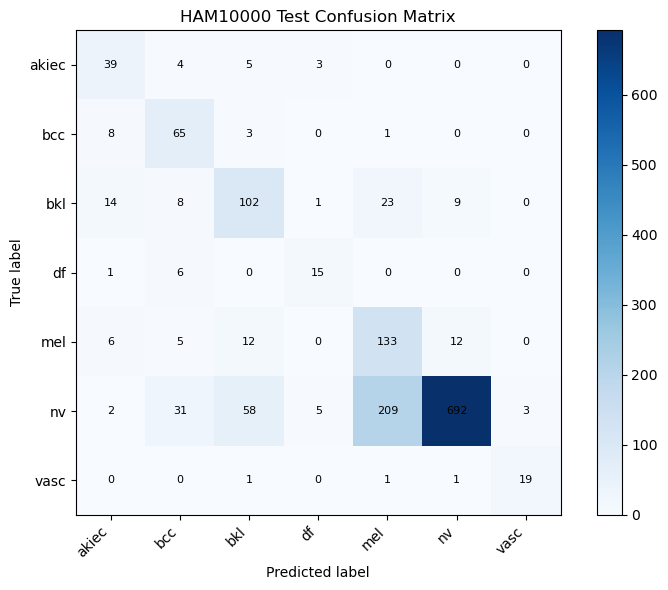

Saved metrics JSON: reports\ham_stage1_metrics_20260410_233416.json
Saved classification report CSV: reports\ham_stage1_classification_report_20260410_233416.csv
Saved confusion matrix PNG: reports\ham_stage1_confusion_matrix_20260410_233416.png
Saved TorchScript model: exports\ham_stage1_efficientnet_b2.ts
ONNX export skipped: Module onnx is not installed!


EfficientNetB2HAM(
  (backbone): EfficientNet(
    (conv_stem): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (bn1): BatchNormAct2d(
      32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
      (drop): Identity()
      (act): SiLU(inplace=True)
    )
    (blocks): Sequential(
      (0): Sequential(
        (0): DepthwiseSeparableConv(
          (conv_dw): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (bn1): BatchNormAct2d(
            32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
            (drop): Identity()
            (act): SiLU(inplace=True)
          )
          (aa): Identity()
          (se): SqueezeExcite(
            (conv_reduce): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (act1): SiLU(inplace=True)
            (conv_expand): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (gate): Sigmoid()
          )
          (conv_

In [6]:
from datetime import datetime
import json

import matplotlib.pyplot as plt
from sklearn.metrics import balanced_accuracy_score, classification_report, confusion_matrix


def load_checkpoint(path: str, device: torch.device):
    # Prefer safe loading for modern PyTorch.
    try:
        return torch.load(path, map_location=device, weights_only=True)
    except TypeError:
        # Older PyTorch versions do not support weights_only.
        return torch.load(path, map_location=device)


def evaluate_detailed(model, loader):
    model.eval()
    losses, y_true, y_pred = [], [], []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(DEVICE, dtype=torch.float32)
            y = y.to(DEVICE)

            logits = model(x)
            loss = criterion(logits, y)

            losses.append(float(loss.detach().cpu().item()))
            preds = torch.argmax(logits, dim=1)
            y_true.extend(y.detach().cpu().numpy().tolist())
            y_pred.extend(preds.detach().cpu().numpy().tolist())

    metrics = {
        'loss': float(np.mean(losses)),
        'acc': float(accuracy_score(y_true, y_pred)),
        'macro_f1': float(f1_score(y_true, y_pred, average='macro', zero_division=0)),
        'balanced_acc': float(balanced_accuracy_score(y_true, y_pred)),
    }
    report = classification_report(y_true, y_pred, target_names=HAM_CLASSES, output_dict=True, zero_division=0)
    cm = confusion_matrix(y_true, y_pred)
    return metrics, report, cm


# 1) Load best checkpoint and evaluate on test set.
ckpt = load_checkpoint('checkpoints/stage1.pth', DEVICE)
model.load_state_dict(ckpt['model_state'])
metrics, report, cm = evaluate_detailed(model, test_loader)
print('Detailed test metrics:', metrics)

# 2) Save report artifacts.
reports_dir = Path('reports')
reports_dir.mkdir(exist_ok=True)

run_stamp = datetime.now().strftime('%Y%m%d_%H%M%S')
metrics_path = reports_dir / f'ham_stage1_metrics_{run_stamp}.json'
report_path = reports_dir / f'ham_stage1_classification_report_{run_stamp}.csv'
cm_path = reports_dir / f'ham_stage1_confusion_matrix_{run_stamp}.png'

with open(metrics_path, 'w', encoding='utf-8') as f:
    json.dump(metrics, f, indent=2)

pd.DataFrame(report).T.to_csv(report_path, index=True)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
ax.set_title('HAM10000 Test Confusion Matrix')
ax.set_xlabel('Predicted label')
ax.set_ylabel('True label')
ax.set_xticks(range(len(HAM_CLASSES)))
ax.set_yticks(range(len(HAM_CLASSES)))
ax.set_xticklabels(HAM_CLASSES, rotation=45, ha='right')
ax.set_yticklabels(HAM_CLASSES)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center', color='black', fontsize=8)

fig.colorbar(im, ax=ax)
fig.tight_layout()
fig.savefig(cm_path, dpi=180)
plt.show()

print('Saved metrics JSON:', metrics_path)
print('Saved classification report CSV:', report_path)
print('Saved confusion matrix PNG:', cm_path)

# 3) Export model for inference.
exports_dir = Path('exports')
exports_dir.mkdir(exist_ok=True)

model_cpu = model.to('cpu').eval()
size = PREPROCESSING_CONFIG['input_size']
dummy_input = torch.randn(1, 3, size, size)

ts_path = exports_dir / 'ham_stage1_efficientnet_b2.ts'
traced = torch.jit.trace(model_cpu, dummy_input)
traced.save(str(ts_path))
print('Saved TorchScript model:', ts_path)

onnx_path = exports_dir / 'ham_stage1_efficientnet_b2.onnx'
try:
    torch.onnx.export(
        model_cpu,
        dummy_input,
        str(onnx_path),
        input_names=['input'],
        output_names=['logits'],
        dynamic_axes={'input': {0: 'batch'}, 'logits': {0: 'batch'}},
        opset_version=17,
    )
    print('Saved ONNX model:', onnx_path)
except Exception as e:
    print('ONNX export skipped:', e)

model.to(DEVICE)

## Stage 2 training from preprocessed ISIC + PAD CSVs (no Stage 1 retrain)

In [5]:
from pathlib import Path
import numpy as np
import pandas as pd
import warnings
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam

import timm
from PIL import Image
from torchvision import transforms
from sklearn.metrics import accuracy_score, f1_score

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Unified classes expected by stage2 labels
UNIFIED_CLASSES = ['MEL','BCC','SCC','AK','NEV','BKL','DF','VASC','SEK','TINEA','PSORIASIS','VITILIGO','MELASMA','FUNGAL','ECZEMA','URTICARIA']
UNIFIED_INDEX = {c:i for i,c in enumerate(UNIFIED_CLASSES)}

PREPROCESSING_CONFIG = {'input_size':260,'mean':[0.485,0.456,0.406],'std':[0.229,0.224,0.225]}

In [3]:
class Stage2Dataset(Dataset):
    def __init__(self, df: pd.DataFrame, mode: str='train'):
        self.df = df.reset_index(drop=True).copy()
        size = PREPROCESSING_CONFIG['input_size']
        mean = PREPROCESSING_CONFIG['mean']
        std = PREPROCESSING_CONFIG['std']
        if mode == 'train':
            self.tr = transforms.Compose([
                transforms.Resize((size,size)),
                transforms.RandomHorizontalFlip(),
                transforms.RandomVerticalFlip(),
                transforms.RandomRotation(20),
                transforms.ColorJitter(brightness=0.5, contrast=0.5, saturation=0.4, hue=0.15),
                transforms.ToTensor(),
                transforms.Normalize(mean,std),
                transforms.RandomErasing(p=0.2),
            ])
        else:
            self.tr = transforms.Compose([
                transforms.Resize((size,size)),
                transforms.ToTensor(),
                transforms.Normalize(mean,std),
            ])

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        r = self.df.iloc[idx]
        p = Path(r['image_path'])
        y = map_label(r['label'])
        if y < 0:
            y = 0
        try:
            img = Image.open(p).convert('RGB')
        except Exception:
            warnings.warn(f'Image issue: {p}. Using black fallback.')
            img = Image.fromarray(np.zeros((260,260,3), dtype=np.uint8))
        return self.tr(img).float(), y

In [7]:
def map_label(raw: str) -> int:
    x = str(raw).strip().lower()
    mapping = {
        'mel':'MEL','nv':'NEV','bcc':'BCC','ak':'AK','akiec':'AK','bkl':'BKL','scc':'SCC','vasc':'VASC','df':'DF',
        'nev':'NEV','ack':'AK','sek':'SEK'
    }
    if raw in UNIFIED_INDEX:
        return UNIFIED_INDEX[raw]
    return UNIFIED_INDEX.get(mapping.get(x,''), -1)

In [8]:
class EfficientNetB2Unified(nn.Module):
    def __init__(self, num_classes: int):
        super().__init__()
        self.backbone = timm.create_model('efficientnet_b2', pretrained=True, num_classes=0, global_pool='')
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.BatchNorm1d(1408),
            nn.Dropout(0.3),
            nn.Linear(1408, num_classes),
        )
    def forward(self, x):
        return self.head(self.backbone.forward_features(x))

In [ ]:
def load_stage1_into_stage2(stage1_path='checkpoints/stage1.pth'):
    stage2_model = EfficientNetB2Unified(num_classes=len(UNIFIED_CLASSES))
    ckpt = torch.load(stage1_path, map_location='cpu')
    state = ckpt['model_state']

    # load backbone / shared layers
    own = stage2_model.state_dict()
    for k,v in state.items():
        if k.startswith('head.4.weight') or k.startswith('head.4.bias'):
            continue
        if k in own and own[k].shape == v.shape:
            own[k] = v

    # expand classifier: copy stage1 rows into matching unified classes
    old_w = state['head.4.weight']
    old_b = state['head.4.bias']
    new_w = own['head.4.weight']
    new_b = own['head.4.bias']
    nn.init.xavier_uniform_(new_w)
    nn.init.zeros_(new_b)

    # stage1 class order in your notebook
    stage1_order = ['akiec','bcc','bkl','df','mel','nv','vasc']
    stage1_to_unified = {'akiec':'AK','bcc':'BCC','bkl':'BKL','df':'DF','mel':'MEL','nv':'NEV','vasc':'VASC'}
    for i, raw in enumerate(stage1_order):
        u = stage1_to_unified[raw]
        j = UNIFIED_INDEX[u]
        new_w[j] = old_w[i]
        new_b[j] = old_b[i]

    stage2_model.load_state_dict(own, strict=False)

    # unfreeze last 5 blocks + head
    for p in stage2_model.backbone.parameters():
        p.requires_grad = False
    for b in list(stage2_model.backbone.blocks)[-5:]:
        for p in b.parameters():
            p.requires_grad = True
    for p in stage2_model.head.parameters():
        p.requires_grad = True

    return stage2_model

train_df = pd.read_csv('data/stage2/stage2_combined_train.csv')
val_df = pd.read_csv('data/stage2/stage2_combined_val.csv')

train_ds = Stage2Dataset(train_df, mode='train')
val_ds = Stage2Dataset(val_df, mode='val')

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=0)

stage2_model = load_stage1_into_stage2('checkpoints/stage1.pth').to(DEVICE)
criterion = nn.CrossEntropyLoss()

backbone_params = [p for n,p in stage2_model.named_parameters() if p.requires_grad and n.startswith('backbone')]
head_params = [p for n,p in stage2_model.named_parameters() if p.requires_grad and n.startswith('head')]
optimizer = Adam([{'params': backbone_params, 'lr': 1e-5}, {'params': head_params, 'lr': 1e-4}], weight_decay=1e-4)

def run_stage2_epoch(model, loader, train=True):
    model.train(train)
    losses=[]; y_true=[]; y_pred=[]
    for x,y in loader:
        x=x.to(DEVICE, dtype=torch.float32); y=y.to(DEVICE)
        if train: optimizer.zero_grad(set_to_none=True)
        logits=model(x)
        loss=criterion(logits,y)
        if train:
            loss.backward()
            optimizer.step()
        losses.append(float(loss.detach().cpu().item()))
        pred=torch.argmax(logits, dim=1)
        y_true.extend(y.detach().cpu().numpy().tolist())
        y_pred.extend(pred.detach().cpu().numpy().tolist())
    return {'loss': float(np.mean(losses)), 'acc': float(accuracy_score(y_true,y_pred)), 'macro_f1': float(f1_score(y_true,y_pred,average='macro', zero_division=0))}

num_epochs = 20
best = float('inf')
Path('checkpoints').mkdir(exist_ok=True)
for epoch in range(1, num_epochs+1):
    tr = run_stage2_epoch(stage2_model, train_loader, train=True)
    va = run_stage2_epoch(stage2_model, val_loader, train=False)
    if va['loss'] < best:
        best = va['loss']
        torch.save({'model_state': stage2_model.state_dict(), 'classes': UNIFIED_CLASSES, 'stage': 2}, 'checkpoints/stage2.pth')
    print(f"[Stage2] Epoch {epoch:02d} | train_loss={tr['loss']:.4f} val_loss={va['loss']:.4f} val_acc={va['acc']:.4f} val_f1={va['macro_f1']:.4f}")

print('Saved best Stage 2 checkpoint: checkpoints/stage2.pth')

C:\Users\prakh\AppData\Local\Temp\ipykernel_9824\4104583995.py:89: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(stage1_path, map_location='cpu')


[Stage2] Epoch 01 | train_loss=1.8790 val_loss=1.3128 val_acc=0.5999 val_f1=0.3550
[Stage2] Epoch 02 | train_loss=1.2172 val_loss=1.1037 val_acc=0.6278 val_f1=0.3435
[Stage2] Epoch 03 | train_loss=1.0780 val_loss=1.0122 val_acc=0.6418 val_f1=0.3695
[Stage2] Epoch 04 | train_loss=1.0014 val_loss=0.9887 val_acc=0.6550 val_f1=0.4140
[Stage2] Epoch 05 | train_loss=0.9633 val_loss=0.9543 val_acc=0.6634 val_f1=0.3995
[Stage2] Epoch 06 | train_loss=0.9194 val_loss=0.9351 val_acc=0.6669 val_f1=0.4286
[Stage2] Epoch 07 | train_loss=0.9013 val_loss=0.9234 val_acc=0.6711 val_f1=0.4400
[Stage2] Epoch 08 | train_loss=0.8829 val_loss=0.9153 val_acc=0.6774 val_f1=0.4645
[Stage2] Epoch 09 | train_loss=0.8642 val_loss=0.8993 val_acc=0.6844 val_f1=0.4560
[Stage2] Epoch 10 | train_loss=0.8416 val_loss=0.8992 val_acc=0.6837 val_f1=0.4696
[Stage2] Epoch 11 | train_loss=0.8245 val_loss=0.8864 val_acc=0.6878 val_f1=0.4784
[Stage2] Epoch 12 | train_loss=0.8194 val_loss=0.8872 val_acc=0.6913 val_f1=0.4827
[Sta

## Testing

### with PAD-UFES-20 dataset

In [17]:
import torch, pandas as pd, numpy as np
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, f1_score, balanced_accuracy_score, classification_report, confusion_matrix

# 1) Smartphone-only test set
pad_test_df = pd.read_csv(r"data\stage2\pad_stage2_test.csv")  # from preprocessing notebook
pad_test_ds = Stage2Dataset(pad_test_df, mode="val")
pad_test_loader = DataLoader(pad_test_ds, batch_size=32, shuffle=False, num_workers=0)

# 2) Load trained Stage 2 checkpoint
model = EfficientNetB2Unified(num_classes=len(UNIFIED_CLASSES)).to(DEVICE)
ckpt = torch.load(r"checkpoints\stage2.pth", map_location=DEVICE, weights_only=True)
model.load_state_dict(ckpt["model_state"])
model.eval()

# 3) Inference
y_true, y_pred = [], []
with torch.no_grad():
    for x, y in pad_test_loader:
        x = x.to(DEVICE, dtype=torch.float32)
        logits = model(x)
        pred = torch.argmax(logits, dim=1).cpu().numpy()
        y_pred.extend(pred.tolist())
        y_true.extend(y.numpy().tolist())

# 4) Metrics
print("PAD (smartphone) Accuracy      :", accuracy_score(y_true, y_pred))
print("PAD (smartphone) Macro F1      :", f1_score(y_true, y_pred, average="macro"))
print("PAD (smartphone) Balanced Acc  :", balanced_accuracy_score(y_true, y_pred))
print(classification_report(
    y_true, y_pred,
    labels=list(range(len(UNIFIED_CLASSES))),
    target_names=UNIFIED_CLASSES,
    zero_division=0
))

PAD (smartphone) Accuracy      : 0.6676300578034682
PAD (smartphone) Macro F1      : 0.4163778749777027
PAD (smartphone) Balanced Acc  : 0.5465608465608466
              precision    recall  f1-score   support

         MEL       0.33      0.20      0.25         5
         BCC       0.68      0.78      0.73       120
         SCC       0.40      0.14      0.21        42
          AK       0.72      0.75      0.73        92
         NEV       0.67      0.71      0.69        42
         BKL       0.00      0.00      0.00         0
          DF       0.00      0.00      0.00         0
        VASC       0.00      0.00      0.00         0
         SEK       0.76      0.69      0.72        45
       TINEA       0.00      0.00      0.00         0
   PSORIASIS       0.00      0.00      0.00         0
    VITILIGO       0.00      0.00      0.00         0
     MELASMA       0.00      0.00      0.00         0
      FUNGAL       0.00      0.00      0.00         0
      ECZEMA       0.00      0.00

c:\Users\prakh\anaconda3\envs\dl\lib\site-packages\sklearn\metrics\_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


### with Combined ISIC + PAD-UFES-20 Dataset

In [18]:
test_df = pd.read_csv(r"data\stage2\stage2_combined_test.csv")
test_ds = Stage2Dataset(test_df, mode="val")
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=0)

y_true, y_pred = [], []
with torch.no_grad():
    for x, y in test_loader:
        x = x.to(DEVICE, dtype=torch.float32)
        pred = model(x).argmax(dim=1).cpu().numpy()
        y_pred.extend(pred.tolist())
        y_true.extend(y.numpy().tolist())

print("Combined Accuracy     :", accuracy_score(y_true, y_pred))
print("Combined Macro F1     :", f1_score(y_true, y_pred, average="macro"))
print("Combined Balanced Acc :", balanced_accuracy_score(y_true, y_pred))

print(classification_report(
    y_true, y_pred,
    labels=list(range(len(UNIFIED_CLASSES))),
    target_names=UNIFIED_CLASSES,
    zero_division=0
))

Combined Accuracy     : 0.6767571329157968
Combined Macro F1     : 0.5637568502522328
Combined Balanced Acc : 0.5309567332789347
              precision    recall  f1-score   support

         MEL       0.73      0.58      0.64       618
         BCC       0.71      0.74      0.72       590
         SCC       0.37      0.18      0.24       131
          AK       0.52      0.44      0.47       222
         NEV       0.71      0.90      0.80       962
         BKL       0.49      0.44      0.46       262
          DF       0.45      0.26      0.33        19
        VASC       0.93      0.56      0.70        25
         SEK       0.72      0.69      0.70        45
       TINEA       0.00      0.00      0.00         0
   PSORIASIS       0.00      0.00      0.00         0
    VITILIGO       0.00      0.00      0.00         0
     MELASMA       0.00      0.00      0.00         0
      FUNGAL       0.00      0.00      0.00         0
      ECZEMA       0.00      0.00      0.00         0
   URT

# Stage 3

In [9]:
import os
from collections import Counter
import pandas as pd

stage3_csv = r'stage3_output\stage3_merged.csv'
if not os.path.exists(stage3_csv):
    raise FileNotFoundError(f'Stage 3 merged CSV not found: {stage3_csv}')

stage3_df = pd.read_csv(stage3_csv)
stage3_df = stage3_df[stage3_df['has_disease_label'].astype(bool)].copy()
stage3_df['label_idx'] = stage3_df['unified_label'].map(lambda x: UNIFIED_INDEX.get(str(x), -1))
stage3_df = stage3_df[stage3_df['label_idx'] >= 0].copy()

if 'split' not in stage3_df.columns:
    stage3_df['split'] = 'train'
stage3_df['split'] = stage3_df['split'].astype(str).str.lower()

train_df3 = stage3_df[stage3_df['split'] == 'train'].reset_index(drop=True)
val_df3 = stage3_df[stage3_df['split'] == 'val'].reset_index(drop=True)
if len(val_df3) == 0:
    val_df3 = stage3_df[stage3_df['split'] == 'test'].reset_index(drop=True)

print('Stage3 train size:', len(train_df3))
print('Stage3 val size  :', len(val_df3))
print('Stage3 source mix (train):')
print(train_df3['dataset_source'].value_counts(dropna=False))

class Stage3Dataset(Dataset):
    def __init__(self, df: pd.DataFrame, mode: str='train'):
        self.df = df.reset_index(drop=True).copy()
        size = PREPROCESSING_CONFIG['input_size']
        mean = PREPROCESSING_CONFIG['mean']
        std = PREPROCESSING_CONFIG['std']
        if mode == 'train':
            self.tr = transforms.Compose([
                transforms.Resize((size, size)),
                transforms.RandomHorizontalFlip(),
                transforms.RandomVerticalFlip(),
                transforms.RandomRotation(20),
                transforms.ColorJitter(brightness=0.5, contrast=0.5, saturation=0.4, hue=0.15),
                transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
                transforms.ToTensor(),
                transforms.Normalize(mean, std),
                transforms.RandomErasing(p=0.2),
            ])
        else:
            self.tr = transforms.Compose([
                transforms.Resize((size, size)),
                transforms.ToTensor(),
                transforms.Normalize(mean, std),
            ])

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        r = self.df.iloc[idx]
        p = Path(r['image_path'])
        y = int(r['label_idx'])
        fst = int(r['fst_group']) if not pd.isna(r['fst_group']) else 0
        try:
            img = Image.open(p).convert('RGB')
        except Exception:
            warnings.warn(f'Image issue: {p}. Using black fallback.')
            img = Image.fromarray(np.zeros((260,260,3), dtype=np.uint8))
        return self.tr(img).float(), y, fst

def build_stage3_sampler(df: pd.DataFrame):
    cls_counts = Counter(df['label_idx'].tolist())
    def band(f):
        if f in [1,2]: return 'light'
        if f in [3,4]: return 'medium'
        if f in [5,6]: return 'dark'
        return 'unknown'
    band_counts = Counter([band(int(v) if not pd.isna(v) else 0) for v in df['fst_group'].tolist()])
    w = []
    for _, r in df.iterrows():
        c = int(r['label_idx'])
        b = band(int(r['fst_group']) if not pd.isna(r['fst_group']) else 0)
        class_w = 1.0 / max(cls_counts.get(c, 1), 1)
        band_w = 1.0 / max(band_counts.get(b, 1), 1) if b != 'unknown' else 1.0
        w.append(class_w * band_w)
    return torch.utils.data.WeightedRandomSampler(torch.tensor(w, dtype=torch.double), num_samples=len(w), replacement=True)

train_ds3 = Stage3Dataset(train_df3, mode='train')
val_ds3 = Stage3Dataset(val_df3, mode='val')
sampler3 = build_stage3_sampler(train_df3)
train_loader3 = DataLoader(train_ds3, batch_size=32, sampler=sampler3, num_workers=0)
val_loader3 = DataLoader(val_ds3, batch_size=32, shuffle=False, num_workers=0)

stage3_model = EfficientNetB2Unified(num_classes=len(UNIFIED_CLASSES)).to(DEVICE)
ckpt2 = torch.load(r'checkpoints\stage2.pth', map_location=DEVICE, weights_only=True)
stage3_model.load_state_dict(ckpt2['model_state'])
for p in stage3_model.parameters():
    p.requires_grad = True

criterion3 = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer3 = Adam(stage3_model.parameters(), lr=5e-5, weight_decay=1e-4)

def run_stage3_epoch(model, loader, train=True):
    model.train(train)
    losses=[]; y_true=[]; y_pred=[]
    for batch in loader:
        x, y, _fst = batch
        x = x.to(DEVICE, dtype=torch.float32)
        y = y.to(DEVICE)
        if train:
            optimizer3.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion3(logits, y)
        if train:
            loss.backward()
            optimizer3.step()
        losses.append(float(loss.detach().cpu().item()))
        pred = torch.argmax(logits, dim=1)
        y_true.extend(y.detach().cpu().numpy().tolist())
        y_pred.extend(pred.detach().cpu().numpy().tolist())
    return {'loss': float(np.mean(losses)), 'acc': float(accuracy_score(y_true, y_pred)), 'macro_f1': float(f1_score(y_true, y_pred, average='macro', zero_division=0))}

best_val_loss = float('inf')
for epoch in range(1, 13):
    tr = run_stage3_epoch(stage3_model, train_loader3, train=True)
    va = run_stage3_epoch(stage3_model, val_loader3, train=False)
    print(f"[Stage3][{epoch:02d}] train_loss={tr['loss']:.4f} acc={tr['acc']:.4f} f1={tr['macro_f1']:.4f} | val_loss={va['loss']:.4f} acc={va['acc']:.4f} f1={va['macro_f1']:.4f}")
    if va['loss'] < best_val_loss:
        best_val_loss = va['loss']
        torch.save({'model_state': stage3_model.state_dict(), 'classes': UNIFIED_CLASSES, 'stage': 3}, 'checkpoints/stage3.pth')

print('Saved best Stage 3 checkpoint: checkpoints/stage3.pth')

Stage3 train size: 12943
Stage3 val size  : 352
Stage3 source mix (train):
dataset_source
dermnet           10390
fitzpatrick17k     2553
Name: count, dtype: int64
[Stage3][01] train_loss=3.9076 acc=0.2279 f1=0.1710 | val_loss=3.3338 acc=0.1676 f1=0.1118
[Stage3][02] train_loss=2.5181 acc=0.3959 f1=0.3031 | val_loss=3.5652 acc=0.1847 f1=0.1195
[Stage3][03] train_loss=2.1795 acc=0.4497 f1=0.3159 | val_loss=3.1683 acc=0.1648 f1=0.1054
[Stage3][04] train_loss=2.0248 acc=0.4973 f1=0.3264 | val_loss=3.1162 acc=0.2074 f1=0.1338
[Stage3][05] train_loss=1.8720 acc=0.5330 f1=0.3516 | val_loss=3.0709 acc=0.1989 f1=0.1353
[Stage3][06] train_loss=1.7476 acc=0.5679 f1=0.3750 | val_loss=3.1582 acc=0.1989 f1=0.1347
[Stage3][07] train_loss=1.6597 acc=0.5846 f1=0.3883 | val_loss=3.0709 acc=0.2301 f1=0.1441
[Stage3][08] train_loss=1.5663 acc=0.6233 f1=0.4438 | val_loss=3.1301 acc=0.2500 f1=0.1512
[Stage3][09] train_loss=1.4988 acc=0.6438 f1=0.4942 | val_loss=3.1476 acc=0.2273 f1=0.1391
[Stage3][10] trai